In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from plot_style import apply_mnras_style, get_single_column_size
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable
import re

data = pd.read_csv('data/slab_geometry_sources_from_reference_articles.csv')
plot_df = data.copy()
FIGURE_DIR = Path('figure')
FIGURE_DIR.mkdir(exist_ok=True)

def parse_cutoff_bounds(value):
    if pd.isna(value):
        return np.nan, np.nan
    text = str(value).strip()
    if not text:
        return np.nan, np.nan
    if text.startswith('>'):
        return float(text[1:].strip()), np.nan

    symmetric = re.fullmatch(r'([0-9.]+)\s*\+/-\s*([0-9.]+)', text)
    if symmetric:
        central, err = map(float, symmetric.groups())
        return central - err, central + err

    asymmetric = re.fullmatch(r'([0-9.]+)\s*\(\+([0-9.]+)/-([0-9.]+)\)', text)
    if asymmetric:
        central, err_plus, err_minus = map(float, asymmetric.groups())
        return central - err_minus, central + err_plus

    return np.nan, np.nan

cutoff_bounds = plot_df['cutoff_energy_keV'].apply(parse_cutoff_bounds)
plot_df['ecut_lower_keV'] = cutoff_bounds.apply(lambda x: x[0])
plot_df['ecut_upper_keV'] = cutoff_bounds.apply(lambda x: x[1])
plot_df['kTe_lower_keV'] = plot_df['kTe_central_keV'] - plot_df['kTe_err_minus_keV'].fillna(0)
plot_df['kTe_upper_keV'] = plot_df['kTe_central_keV'] + plot_df['kTe_err_plus_keV'].fillna(0)
plot_df['tau_lower'] = plot_df['tau_central'] - plot_df['tau_err_minus'].fillna(0)
plot_df['tau_upper'] = plot_df['tau_central'] + plot_df['tau_err_plus'].fillna(0)

serafinelli_sources = set(
    plot_df.loc[plot_df['article'].eq('Serafinelli et al. 2024'), 'source'].dropna()
)
plot_df['exclude_t18_reanalysed_by_s24'] = (
    plot_df['article'].eq('Tortosa et al. 2018')
    & plot_df['source'].isin(serafinelli_sources)
)

base_df = plot_df[
    plot_df['kTe_central_keV'].notna()
    & plot_df['tau_central'].notna()
    & plot_df['lambda_edd'].notna()
    & (plot_df['kTe_central_keV'] > 0)
    & (plot_df['tau_central'] > 0)
    & (plot_df['kTe_lower_keV'] > 0)
    & (plot_df['tau_lower'] > 0)
    & ~plot_df['exclude_t18_reanalysed_by_s24']
].copy()

base_df['exclude_ecut_consistency'] = (
    (base_df['ecut_lower_keV'].notna() & (base_df['kTe_upper_keV'] < base_df['ecut_lower_keV'] / 3.0))
    | (base_df['ecut_upper_keV'].notna() & (base_df['kTe_lower_keV'] > base_df['ecut_upper_keV'] / 2.0))
)
base_df['exclude_lambda_range'] = ~((base_df['lambda_edd'] > 0.01) & (base_df['lambda_edd'] <= 2))
base_df['exclude_moca'] = base_df['compton_model_or_extrapolation'].fillna('').str.contains('moca', case=False, na=False)
base_df['excluded_by_cleaning'] = (
    base_df['exclude_lambda_range']
    | base_df['exclude_moca']
    | base_df['exclude_ecut_consistency']
)

kept_df = base_df[~base_df['excluded_by_cleaning']].copy()
removed_df = base_df[base_df['excluded_by_cleaning']].copy()


print(f'Total plotted sample size: {len(base_df)}')
print(f'Kept sample size: {len(kept_df)}')
print(f'Removed sample size: {len(removed_df)}')

Total plotted sample size: 26
Kept sample size: 19
Removed sample size: 7


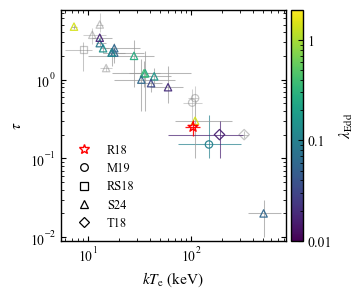

In [28]:
apply_mnras_style()
row_height_scale = 1.0
cmap_name = 'viridis'

for col in [
    'kTe_central_keV', 'kTe_err_minus_keV', 'kTe_err_plus_keV',
    'tau_central', 'tau_err_minus', 'tau_err_plus', 'lambda_edd'
]:
    plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')

article_label_map = {
    'Marinucci et al. 2019': 'M19',
    'Rani and Stalin 2018': 'RS18',
    'Serafinelli et al. 2024': 'S24',
    'Tortosa et al. 2018': 'T18',
}

marker_map = {
    article: marker
    for article, marker in zip(
        sorted(base_df['article'].dropna().unique()),
        ['o', 's', '^', 'D', 'v', 'P', 'X', '<', '>', 'h']
    )
}

norm = LogNorm(vmin=0.01, vmax=2)
cmap = plt.get_cmap(cmap_name)

fig, ax = plt.subplots(figsize=get_single_column_size(row_height_scale=row_height_scale))


def draw_group(frame, use_colorbar):
    for article, sub in frame.groupby('article', dropna=False):
        marker = marker_map.get(article, 'o')
        xerr = np.vstack([
            sub['kTe_central_keV'] - sub['kTe_lower_keV'],
            sub['kTe_upper_keV'] - sub['kTe_central_keV'],
        ])
        yerr = np.vstack([
            sub['tau_central'] - sub['tau_lower'],
            sub['tau_upper'] - sub['tau_central'],
        ])

        if use_colorbar:
            edgecolors = cmap(norm(sub['lambda_edd'].to_numpy()))
        else:
            edgecolors = [(0.5, 0.5, 0.5, 0.45)] * len(sub)

        ax.errorbar(
            sub['kTe_central_keV'],
            sub['tau_central'],
            xerr=xerr,
            yerr=yerr,
            fmt='none',
            ecolor=edgecolors[0] if len(sub) == 1 else '0.6',
            elinewidth=0.75,
            capsize=0,
            alpha=0.45 if not use_colorbar else 0.7,
            zorder=1 if not use_colorbar else 2,
        )
        ax.scatter(
            sub['kTe_central_keV'],
            sub['tau_central'],
            facecolors='none',
            edgecolors=edgecolors,
            marker=marker,
            s=28,
            linewidths=0.9,
            alpha=0.45 if not use_colorbar else 0.95,
            zorder=2 if not use_colorbar else 3,
        )


draw_group(removed_df, use_colorbar=False)
draw_group(kept_df, use_colorbar=True)

ricci_kte = 105
ricci_kte_err = 18
ricci_tau = 0.25
ricci_tau_err = 0.06
ax.errorbar(
    [ricci_kte],
    [ricci_tau],
    xerr=[[ricci_kte_err], [ricci_kte_err]],
    yerr=[[ricci_tau_err], [ricci_tau_err]],
    fmt='none',
    ecolor='red',
    elinewidth=0.9,
    capsize=0,
    alpha=0.9,
    zorder=4,
)
ax.scatter(
    [ricci_kte],
    [ricci_tau],
    facecolors='none',
    edgecolors='red',
    marker='*',
    s=56,
    linewidths=1.0,
    alpha=1.0,
    zorder=5,
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$kT_{\mathrm{e}}$ (keV)')
ax.set_ylabel(r'$\tau$')
ax.grid(False)

combined = base_df[['kTe_lower_keV', 'kTe_upper_keV', 'tau_lower', 'tau_upper']]
ax.set_xlim(combined['kTe_lower_keV'].min() * 0.9, combined['kTe_upper_keV'].max() * 1.1)
ax.set_ylim(combined['tau_lower'].min() * 0.9, combined['tau_upper'].max() * 1.1)

xlim = ax.get_xlim()
ylim = ax.get_ylim()

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_ticks([0.01, 0.1, 1])
cbar.set_ticklabels(['0.01', '0.1', '1'])
cbar.set_label(r'$\lambda_{\mathrm{Edd}}$')

legend_handles = []
legend_labels = []
legend_handles.append(
    plt.Line2D([], [], linestyle='none', marker='*', markersize=7.8,
               markerfacecolor='none', markeredgecolor='red', markeredgewidth=1.0)
)
legend_labels.append('R18')
for article in sorted(base_df['article'].dropna().unique()):
    legend_handles.append(
        plt.Line2D([], [], linestyle='none', marker=marker_map[article], markersize=5.5,
                   markerfacecolor='none', markeredgecolor='black', markeredgewidth=0.9)
    )
    legend_labels.append(article_label_map.get(article, article))
ax.legend(legend_handles, legend_labels, loc='lower left', frameon=False)

fig.savefig(FIGURE_DIR / 'cleaned_scatter_colorbar_main.pdf', dpi=300, bbox_inches='tight')
plt.show()


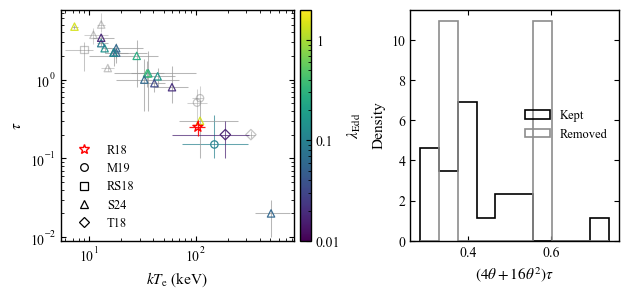

In [29]:
from plot_style import get_double_column_size

apply_mnras_style()

fig, (ax_left, ax_right) = plt.subplots(
    1,
    2,
    figsize=get_double_column_size(row_height_scale=1.0),
    gridspec_kw={'wspace': 0.28, 'width_ratios': [1.35, 1.0]},
)


def draw_group(ax, frame, use_colorbar):
    for article, sub in frame.groupby('article', dropna=False):
        marker = marker_map.get(article, 'o')
        xerr = np.vstack([
            sub['kTe_central_keV'] - sub['kTe_lower_keV'],
            sub['kTe_upper_keV'] - sub['kTe_central_keV'],
        ])
        yerr = np.vstack([
            sub['tau_central'] - sub['tau_lower'],
            sub['tau_upper'] - sub['tau_central'],
        ])

        if use_colorbar:
            edgecolors = cmap(norm(sub['lambda_edd'].to_numpy()))
        else:
            edgecolors = [(0.5, 0.5, 0.5, 0.45)] * len(sub)

        ax.errorbar(
            sub['kTe_central_keV'],
            sub['tau_central'],
            xerr=xerr,
            yerr=yerr,
            fmt='none',
            ecolor=edgecolors[0] if len(sub) == 1 else '0.6',
            elinewidth=0.75,
            capsize=0,
            alpha=0.45 if not use_colorbar else 0.7,
            zorder=1 if not use_colorbar else 2,
        )
        ax.scatter(
            sub['kTe_central_keV'],
            sub['tau_central'],
            facecolors='none',
            edgecolors=edgecolors,
            marker=marker,
            s=28,
            linewidths=0.9,
            alpha=0.45 if not use_colorbar else 0.95,
            zorder=2 if not use_colorbar else 3,
        )


draw_group(ax_left, removed_df, use_colorbar=False)
draw_group(ax_left, kept_df, use_colorbar=True)

ricci_kte = 105
ricci_kte_err = 18
ricci_tau = 0.25
ricci_tau_err = 0.06
ax_left.errorbar(
    [ricci_kte],
    [ricci_tau],
    xerr=[[ricci_kte_err], [ricci_kte_err]],
    yerr=[[ricci_tau_err], [ricci_tau_err]],
    fmt='none',
    ecolor='red',
    elinewidth=0.9,
    capsize=0,
    alpha=0.9,
    zorder=4,
)
ax_left.scatter(
    [ricci_kte],
    [ricci_tau],
    facecolors='none',
    edgecolors='red',
    marker='*',
    s=56,
    linewidths=1.0,
    alpha=1.0,
    zorder=5,
)

ax_left.set_xscale('log')
ax_left.set_yscale('log')
ax_left.set_xlabel(r'$kT_{\mathrm{e}}$ (keV)')
ax_left.set_ylabel(r'$\tau$')
ax_left.grid(False)

combined = base_df[['kTe_lower_keV', 'kTe_upper_keV', 'tau_lower', 'tau_upper']]
ax_left.set_xlim(combined['kTe_lower_keV'].min() * 0.9, combined['kTe_upper_keV'].max() * 1.1)
ax_left.set_ylim(combined['tau_lower'].min() * 0.9, combined['tau_upper'].max() * 1.1)

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_left, pad=0.02)
cbar.set_ticks([0.01, 0.1, 1])
cbar.set_ticklabels(['0.01', '0.1', '1'])
cbar.set_label(r'$\lambda_{\mathrm{Edd}}$')

legend_handles = [
    plt.Line2D([], [], linestyle='none', marker='*', markersize=7.8,
               markerfacecolor='none', markeredgecolor='red', markeredgewidth=1.0)
]
legend_labels = ['R18']
for article in sorted(base_df['article'].dropna().unique()):
    legend_handles.append(
        plt.Line2D([], [], linestyle='none', marker=marker_map[article], markersize=5.5,
                   markerfacecolor='none', markeredgecolor='black', markeredgewidth=0.9)
    )
    legend_labels.append(article_label_map.get(article, article))
ax_left.legend(legend_handles, legend_labels, loc='lower left', frameon=False)

kept_theta = kept_df['kTe_central_keV'] / 511
removed_theta = removed_df['kTe_central_keV'] / 511
kept_metric = (4 * kept_theta + 16 * kept_theta**2) * kept_df['tau_central']
removed_metric = (4 * removed_theta + 16 * removed_theta**2) * removed_df['tau_central']
all_metric = pd.concat([kept_metric, removed_metric], ignore_index=True).dropna()
bins = np.histogram_bin_edges(kept_metric, bins=10)

ax_right.hist(
    kept_metric,
    bins=bins,
    density=True,
    histtype='step',
    linewidth=1.2,
    color='black',
    label='Kept',
)
ax_right.hist(
    removed_metric,
    bins=bins,
    density=True,
    histtype='step',
    linewidth=1.2,
    color='0.55',
    label='Removed',
)
ax_right.set_xlabel(r'$(4\theta + 16\theta^2)\tau$')
ax_right.set_ylabel('Density')
ax_right.grid(False)
ax_right.legend(frameon=False, loc='best')

fig.savefig(FIGURE_DIR / 'double_column_scatter_hist.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [30]:
# Cleaned-sample y statistics
theta_clean = kept_df['kTe_central_keV'] / 511.0
y_clean = 4.0 * theta_clean * (1.0 + 4.0 * theta_clean) * kept_df['tau_central']
y_clean = y_clean.replace([np.inf, -np.inf], np.nan).dropna()
y_clean = y_clean[y_clean > 0]

y_0 = y_clean.mean()
delta = np.log10(y_clean) - np.log10(y_0)
dex = np.std(delta)

print(f'n_clean = {len(y_clean)}')
print(f'y_0 = {y_0:.6f}')
print(f'dex = {dex:.6f}')

n_clean = 19
y_0 = 0.414222
dex = 0.101451


xlim = (5.4, 836)
ylim = (0.009, 7.7)


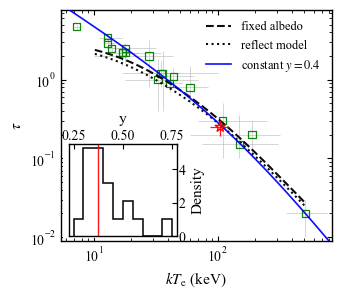

In [31]:
from pathlib import Path

from matplotlib.patches import Rectangle

required_vars = ['kept_df']
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise RuntimeError(
        f"Missing required variables: {missing}. Please run Cells 1-5 first."
    )

apply_mnras_style()
fig, ax = plt.subplots(figsize=get_single_column_size(row_height_scale=1.0))

for article, sub in kept_df.groupby('article', dropna=False):
    xerr = np.vstack([
        sub['kTe_central_keV'] - sub['kTe_lower_keV'],
        sub['kTe_upper_keV'] - sub['kTe_central_keV'],
    ])
    yerr = np.vstack([
        sub['tau_central'] - sub['tau_lower'],
        sub['tau_upper'] - sub['tau_central'],
    ])

    ax.errorbar(
        sub['kTe_central_keV'],
        sub['tau_central'],
        xerr=xerr,
        yerr=yerr,
        fmt='none',
        ecolor='0.7',
        elinewidth=0.7,
        capsize=0,
        alpha=0.55,
        zorder=1,
    )
    ax.scatter(
        sub['kTe_central_keV'],
        sub['tau_central'],
        facecolors='none',
        edgecolors='green',
        marker='s',
        s=28,
        linewidths=0.9,
        alpha=0.95,
        zorder=2,
    )

ricci_kte = 105
ricci_kte_err = 18
ricci_tau = 0.25
ricci_tau_err = 0.06
ricci_theta = ricci_kte / 511
ricci_y = 4 * ricci_theta * (1 + 4 * ricci_theta) * ricci_tau
ax.errorbar(
    [ricci_kte],
    [ricci_tau],
    xerr=[[ricci_kte_err], [ricci_kte_err]],
    yerr=[[ricci_tau_err], [ricci_tau_err]],
    fmt='none',
    ecolor='red',
    elinewidth=0.9,
    capsize=0,
    alpha=0.9,
    zorder=4,
)
ax.scatter(
    [ricci_kte],
    [ricci_tau],
    facecolors='none',
    edgecolors='red',
    marker='*',
    s=56,
    linewidths=1.0,
    alpha=1.0,
    zorder=5,
)

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$kT_{\mathrm{e}}$ (keV)')
ax.set_ylabel(r'$\tau$')
ax.grid(False)


print(f'xlim = ({xlim[0]:.6g}, {xlim[1]:.6g})')
print(f'ylim = ({ylim[0]:.6g}, {ylim[1]:.6g})')

pair_balance_path = 'data/ps96_slab_pair_line_reflection_compare_theta_0.02_1.0_log50.csv'
pair_df = pd.read_csv(pair_balance_path)
curve_df = pair_df[['kTe_keV', 'tau_T_fixed', 'tau_T_reflect']].dropna().sort_values('kTe_keV')

ax.plot(
    curve_df['kTe_keV'],
    curve_df['tau_T_fixed'],
    linewidth=1.5,
    linestyle='--',
    color='k',
    label=r'fixed albedo',
    zorder=3,
    alpha=0.95,
    )
ax.plot(
    curve_df['kTe_keV'],
    curve_df['tau_T_reflect'],
    linestyle=':',
    linewidth=1.5,
    color='k',
    label='reflect model',
    zorder=3,
    alpha=0.95,
    )

x_curve = np.logspace(np.log10(xlim[0]), np.log10(xlim[1]), 300)
theta_curve = x_curve / 511.0

# if 'y_0' not in globals() or not np.isfinite(y_0) or y_0 <= 0:
#     theta_clean = kept_df['kTe_central_keV'] / 511.0
#     y_clean = 4.0 * theta_clean * (1.0 + 4.0 * theta_clean) * kept_df['tau_central']
#     y_clean = y_clean.replace([np.inf, -np.inf], np.nan).dropna()
#     y_clean = y_clean[y_clean > 0]
#     y_0 = y_clean.mean()
# tau_y0_curve = y_0 / (4.0 * theta_curve * (1.0 + 4.0 * theta_curve))
# valid = np.isfinite(tau_y0_curve) & (tau_y0_curve > 0)
# ax.plot(
#     x_curve[valid],
#     tau_y0_curve[valid],
#     linewidth=1.2,
#     color='blue',
#     alpha=0.95,
#     zorder=3,
#     label=fr'constant $y= {y_0:.2f}$',
#     )

tau_y0_curve = 0.4 / (4.0 * theta_curve * (1.0 + 4.0 * theta_curve))
valid = np.isfinite(tau_y0_curve) & (tau_y0_curve > 0)
ax.plot(
    x_curve[valid],
    tau_y0_curve[valid],
    linewidth=1.2,
    color='blue',
    alpha=0.95,
    zorder=3,
    label=fr'constant $y = 0.4$',
    )

# simple_curve = 0.4 / (4.0 * theta_curve)
# valid = np.isfinite(simple_curve) & (simple_curve > 0)
# ax.plot(
#     x_curve[valid],
#     simple_curve[valid],
#     linewidth=1.2,
#     color='blue',
#     alpha=0.95,
#     zorder=3,
#     label=fr'$4\theta\tau= 0.4$',
#     )

# complex_curve = 0.4 / (4.0 * theta_curve * (1.0 + 4.0 * theta_curve))
# complex_curve = np.array([tau if tau < 1 else np.sqrt(tau) for tau in complex_curve])
# valid = np.isfinite(complex_curve) & (complex_curve > 0)
# ax.plot(
#     x_curve[valid],
#     complex_curve[valid],
#     linewidth=1.2,
#     color='blue',
#     alpha=0.95,
#     zorder=3,
#     label=fr'$(4\theta + 16\theta^2)(\tau + \tau^2)= 0.4$',
#     )



kept_theta = kept_df['kTe_central_keV'] / 511
kept_y = 4 * kept_theta * (1 + 4 * kept_theta) * kept_df['tau_central']
kept_y = kept_y.dropna()
y_bins = np.histogram_bin_edges(np.linspace(0.25, 0.75, 20), bins=10)
ax_inset = ax.inset_axes([0.03, 0.02, 0.4, 0.4])
ax_inset.set_zorder(7)


mask = Rectangle(
    (0.01, 0.01),
    0.4,
    0.5,
    transform=ax.transAxes,
    facecolor='white',
    edgecolor='none',
    zorder=6,
    clip_on=False,
    )
ax.add_patch(mask)
ax_inset.hist(
    kept_y,
    bins=y_bins,
    density=True,
    histtype='step',
    linewidth=1.1,
    color='black',
    )
ax_inset.axvline(ricci_y, color='red', linewidth=1.0, alpha=0.9)
ax_inset.set_xlabel('y')
ax_inset.xaxis.set_label_position('top')
ax_inset.xaxis.tick_top()
ax_inset.set_ylabel('Density')
ax_inset.yaxis.set_label_position('right')
ax_inset.yaxis.tick_right()
ax_inset.tick_params(axis='both', pad=1)
ax_inset.grid(False)
ax_inset.set_facecolor('white')

ax.legend(frameon=False, loc='upper right')
fig.savefig(FIGURE_DIR / 'cleaned_scatter_inset_ricci_mask.pdf', dpi=300, bbox_inches='tight')
plt.show()

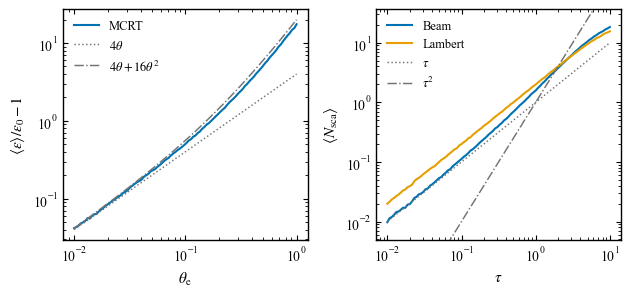

In [32]:
from plot_style import get_double_column_size

apply_mnras_style()

theta_scan_df = pd.read_csv('data/single_scatter_theta_sweep_summary.csv').sort_values('theta_e_mec2')
beam_tau_df = pd.read_csv('data/beam_tau_scan_summary.csv').sort_values('slab_tau')
lambert_tau_df = pd.read_csv('data/lambert_tau_scan_summary.csv').sort_values('slab_tau')

fig, (ax_left, ax_right) = plt.subplots(
    1,
    2,
    figsize=get_double_column_size(row_height_scale=1.0),
    gridspec_kw={'wspace': 0.28},
)

theta_grid = theta_scan_df['theta_e_mec2']
tau_grid = beam_tau_df['slab_tau']

ax_left.plot(
    theta_scan_df['theta_e_mec2'],
    theta_scan_df['mean_energy_gain_over_incident'],
    color='#0072B2',
    linewidth=1.5,
    label='MCRT',
)
ax_left.plot(theta_grid, 4 * theta_grid, color='0.45', linewidth=1.05, linestyle=':', label=r'$4\theta$')
ax_left.plot(theta_grid, 4 * theta_grid + 16 * theta_grid**2, color='0.45', linewidth=1.05, linestyle='-.', label=r'$4\theta + 16\theta^2$')
ax_left.set_xscale('log')
ax_left.set_yscale('log')
ax_left.set_xlabel(r'$\theta_{\rm e}$')
ax_left.set_ylabel(r'$\langle \epsilon \rangle / \epsilon_0 - 1$')
ax_left.grid(False)
ax_left.legend(frameon=False, loc='best')

ax_right.plot(
    beam_tau_df['slab_tau'],
    beam_tau_df['mean_scatter_count'],
    color='#0072B2',
    linewidth=1.5,
    label='Beam',
)
ax_right.plot(
    lambert_tau_df['slab_tau'],
    lambert_tau_df['mean_scatter_count'],
    color='#E69F00',
    linewidth=1.5,
    label='Lambert',
)
right_y_data = pd.concat([
    beam_tau_df['mean_scatter_count'],
    lambert_tau_df['mean_scatter_count'],
], ignore_index=True)
ax_right.plot(tau_grid, tau_grid, color='0.45', linewidth=1.05, linestyle=':', label=r'$\tau$')
ax_right.plot(tau_grid, tau_grid**2, color='0.45', linewidth=1.05, linestyle='-.', label=r'$\tau^2$')
ax_right.set_xscale('log')
ax_right.set_yscale('log')
ax_right.set_ylim(right_y_data.min() * 0.5, right_y_data.max() * 2)
ax_right.set_xlabel(r'$\tau$')
ax_right.set_ylabel(r'$\langle N_{\rm sca} \rangle$')
ax_right.grid(False)
ax_right.legend(frameon=False, loc='best')

fig.savefig(FIGURE_DIR / 'temperature_tau_scan_double_column.pdf', dpi=300, bbox_inches='tight')
plt.show()


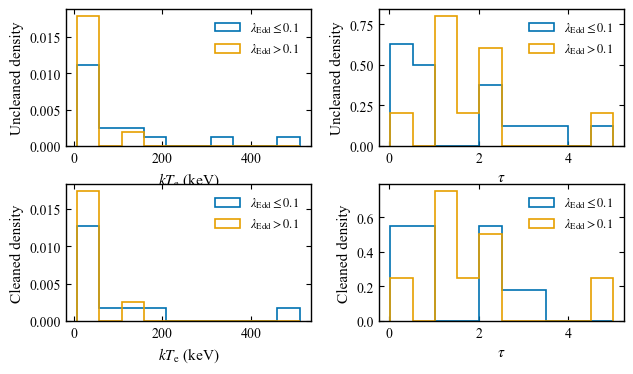

Uncleaned:
  lambda_edd vs kT_e: rho = -0.0810, p = 0.6939
  lambda_edd vs tau: rho = -0.0399, p = 0.8465
Cleaned:
  lambda_edd vs kT_e: rho = -0.1741, p = 0.4758
  lambda_edd vs tau: rho = 0.1827, p = 0.454


In [33]:
from plot_style import get_double_column_size
apply_mnras_style()

from scipy.stats import spearmanr

uncleaned_df = base_df.copy()
cleaned_df = kept_df.copy()

datasets = [
    ('Uncleaned', uncleaned_df),
    ('Cleaned', cleaned_df),
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=get_double_column_size(row_height_scale=1.35),
    gridspec_kw={'wspace': 0.28, 'hspace': 0.28},
)

kte_all = pd.concat([uncleaned_df['kTe_central_keV'], cleaned_df['kTe_central_keV']], ignore_index=True)
tau_all = pd.concat([uncleaned_df['tau_central'], cleaned_df['tau_central']], ignore_index=True)
kte_bins = np.histogram_bin_edges(kte_all, bins=10)
tau_bins = np.histogram_bin_edges(tau_all, bins=10)

for row, (label, df_current) in enumerate(datasets):
    low_df = df_current[df_current['lambda_edd'] <= 0.1]
    high_df = df_current[df_current['lambda_edd'] > 0.1]

    ax_kte = axes[row, 0]
    ax_tau = axes[row, 1]

    ax_kte.hist(low_df['kTe_central_keV'], bins=kte_bins, density=True, histtype='step', linewidth=1.2, color='#0072B2', label=r'$\lambda_{\rm Edd} \leq 0.1$')
    ax_kte.hist(high_df['kTe_central_keV'], bins=kte_bins, density=True, histtype='step', linewidth=1.2, color='#E69F00', label=r'$\lambda_{\rm Edd} > 0.1$')
    ax_kte.set_ylabel(f'{label} density')
    ax_kte.set_xlabel(r'$kT_{\rm e}$ (keV)')
    ax_kte.grid(False)
    ax_kte.legend(frameon=False, loc='best')

    ax_tau.hist(low_df['tau_central'], bins=tau_bins, density=True, histtype='step', linewidth=1.2, color='#0072B2', label=r'$\lambda_{\rm Edd} \leq 0.1$')
    ax_tau.hist(high_df['tau_central'], bins=tau_bins, density=True, histtype='step', linewidth=1.2, color='#E69F00', label=r'$\lambda_{\rm Edd} > 0.1$')
    ax_tau.set_ylabel(f'{label} density')
    ax_tau.set_xlabel(r'$\tau$')
    ax_tau.grid(False)
    ax_tau.legend(frameon=False, loc='best')

fig.savefig(FIGURE_DIR / 'eddington_binned_histograms_and_spearman.pdf', dpi=300, bbox_inches='tight')
plt.show()

for label, df_current in datasets:
    rho_kte, p_kte = spearmanr(df_current['lambda_edd'], df_current['kTe_central_keV'])
    rho_tau, p_tau = spearmanr(df_current['lambda_edd'], df_current['tau_central'])
    print(f'{label}:')
    print(f'  lambda_edd vs kT_e: rho = {rho_kte:.4f}, p = {p_kte:.4g}')
    print(f'  lambda_edd vs tau: rho = {rho_tau:.4f}, p = {p_tau:.4g}')


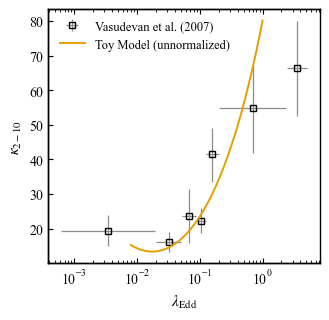

In [34]:
apply_mnras_style()

import mpmath as mp

vasudevan_df = pd.read_csv('data/vasudevan07_calibrated_bined_correction')
vasudevan_df.columns = vasudevan_df.columns.str.strip()
vasudevan_df = vasudevan_df.sort_values('lambda_edd')

lambda_grid = np.logspace(-2.1, 0, 300)
alpha_grid = 0.34 * np.log10(lambda_grid) + 1.34

model_ratio = []
for alpha in alpha_grid:
    s = 1.0 - alpha
    numerator = mp.gammainc(s, 0.1 / 50.0, 500.0 / 50.0)
    denominator = mp.gammainc(s, 2.0 / 50.0, 10.0 / 50.0)
    model_ratio.append(float(numerator / denominator))
model_ratio = np.asarray(model_ratio)

fig, ax_left = plt.subplots(figsize=get_single_column_size(row_height_scale=1.1))
ax_right = ax_left.twinx()

yerr = np.vstack([
    vasudevan_df['kappa2_10'] - vasudevan_df['low_kappa'],
    vasudevan_df['up_kappa'] - vasudevan_df['kappa2_10'],
])
xerr = np.vstack([
    vasudevan_df['lambda_edd'] - vasudevan_df['low_mdot'],
    vasudevan_df['up_mdot'] - vasudevan_df['lambda_edd'],
])

ax_left.errorbar(
    vasudevan_df['lambda_edd'],
    vasudevan_df['kappa2_10'],
    xerr=xerr,
    yerr=yerr,
    fmt='s',
    markersize=5,
    markerfacecolor='none',
    color='black',
    ecolor='0.55',
    elinewidth=0.9,
    capsize=0,
    linewidth=1.2,
    label='Vasudevan et al. (2007)',
)
ax_right.plot(
    lambda_grid,
    model_ratio,
    color='#E69F00',
    linewidth=1.4,
    label='Toy Model (unnormalized)',
)

ax_left.set_xscale('log')
ax_left.set_xlabel(r'$\lambda_{\rm Edd}$')
ax_left.set_ylabel(r'$\kappa_{2-10}$')
ax_left.grid(False)

ax_right.tick_params(right=False, labelright=False)
ax_right.spines['right'].set_visible(False)
ax_right.set_ylabel('')

handles_left, labels_left = ax_left.get_legend_handles_labels()
handles_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(handles_left + handles_right, labels_left + labels_right, frameon=False, loc='upper left')

fig.savefig(FIGURE_DIR / 'vasudevan07_vs_toy_model.pdf', dpi=300, bbox_inches='tight')
plt.show()


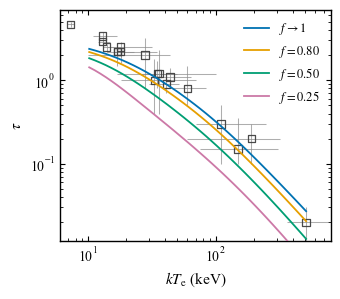

In [35]:
apply_mnras_style()

ps96_df = pd.read_csv('data/ps96_slab_dratio_tau_kTe_theta_0.02_1.0_log40.csv').sort_values(['d_ratio', 'kTe_keV'])
ps96_df['f_value'] = 1.0 / (1.0 + ps96_df['d_ratio'])

fig, ax = plt.subplots(figsize=get_single_column_size(row_height_scale=1.0))

for article, sub in kept_df.groupby('article', dropna=False):
    marker = 's'
    xerr = np.vstack([
        sub['kTe_central_keV'] - sub['kTe_lower_keV'],
        sub['kTe_upper_keV'] - sub['kTe_central_keV'],
    ])
    yerr = np.vstack([
        sub['tau_central'] - sub['tau_lower'],
        sub['tau_upper'] - sub['tau_central'],
    ])
    ax.errorbar(
        sub['kTe_central_keV'],
        sub['tau_central'],
        xerr=xerr,
        yerr=yerr,
        fmt='none',
        ecolor='0.55',
        elinewidth=0.75,
        capsize=0,
        alpha=0.7,
        zorder=1,
    )
    ax.scatter(
        sub['kTe_central_keV'],
        sub['tau_central'],
        facecolors='none',
        edgecolors='0.25',
        marker=marker,
        s=28,
        linewidths=0.9,
        alpha=0.95,
        zorder=2,
    )

curve_colors = ['#0072B2', '#E69F00', '#009E73', '#CC79A7']
for color, (d_value, sub) in zip(curve_colors, ps96_df.groupby('d_ratio', sort=True)):
    f_value = 1.0 / (1.0 + d_value)
    ax.plot(
        sub['kTe_keV'],
        sub['tau_T'],
        color=color,
        linewidth=1.3,
        label=fr'$f = {f_value:.2f}$' if np.abs(f_value - 1.0) > 1e-3 else fr'$f \rightarrow 1$',
        zorder=3,
    )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(6, 800)
ax.set_ylim(0.012, 7)
ax.set_xlabel(r'$kT_{\rm e}$ (keV)')
ax.set_ylabel(r'$\tau$')
ax.grid(False)
ax.legend(frameon=False, loc='best')

fig.savefig(FIGURE_DIR / 'cleaned_data_with_ps96_curves.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
import pandas as pd
import re
from pathlib import Path

latex_article_map = {
    'Marinucci et al. 2019': 'M19',
    'Rani and Stalin 2018': 'RS18',
    'Serafinelli et al. 2024': 'S24',
    'Tortosa et al. 2018': 'T18',
}


def latex_escape(text):
    text = str(text)
    replacements = {
        '&': r'\&',
        '%': r'\%',
        '_': r'\_',
        '#': r'\#',
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text


def format_plain_number(value):
    if pd.isna(value):
        return '-'
    return format(float(value), '.15g')


def format_measurement(central, err_minus, err_plus, limit):
    if pd.notna(limit):
        return latex_escape(limit)
    if pd.isna(central):
        return '-'
    c = format_plain_number(central)
    if pd.notna(err_minus) and pd.notna(err_plus):
        em = format_plain_number(err_minus)
        ep = format_plain_number(err_plus)
        if abs(float(err_minus) - float(err_plus)) < 1e-12:
            return f'${c}' + r'\pm' + f'{ep}$'
        return f'${c}^{{+{ep}}}_{{-{em}}}$'
    return f'${c}$'


def format_lambda(value):
    if pd.isna(value):
        return '-'
    return f'${value:.3f}$'


def format_cutoff(value):
    if pd.isna(value) or str(value).strip() == '':
        return '-'
    text = str(value).strip()
    if text.startswith('>'):
        return f'$>{text[1:].strip()}$'
    symmetric = re.fullmatch(r'([0-9.]+)\s*\+/-\s*([0-9.]+)', text)
    if symmetric:
        central, err = map(float, symmetric.groups())
        return f'${central:.0f}\pm{err:.0f}$'
    asymmetric = re.fullmatch(r'([0-9.]+)\s*\(\+([0-9.]+)/-([0-9.]+)\)', text)
    if asymmetric:
        central, err_plus, err_minus = map(float, asymmetric.groups())
        return f'${central:.0f}^{{+{err_plus:.0f}}}_{{-{err_minus:.0f}}}$'
    return latex_escape(text)


def format_model(value):
    if pd.isna(value) or str(value).strip() == '':
        return '-'
    raw = str(value).strip()
    if raw.lower() == 'comptt (slab)':
        return 'COMPTT'
    text = raw.upper().replace('MOCA', 'MoCA')
    return latex_escape(text)


sample_df = pd.read_csv('data/slab_geometry_sources_from_reference_articles.csv')
sample_df['ref_short'] = sample_df['article'].map(latex_article_map).fillna(sample_df['article'])
sample_df['Source'] = sample_df['source'].fillna('-').map(latex_escape)
sample_df['Ref.'] = sample_df['ref_short'].map(latex_escape)
sample_df[r'$E_{\rm cut}$ (keV)'] = sample_df['cutoff_energy_keV'].apply(format_cutoff)
sample_df[r'$kT_{\rm e}$ (keV)'] = sample_df.apply(
    lambda row: format_measurement(row['kTe_central_keV'], row['kTe_err_minus_keV'], row['kTe_err_plus_keV'], row['kTe_limit']),
    axis=1,
)
sample_df[r'$\tau$'] = sample_df.apply(
    lambda row: format_measurement(row['tau_central'], row['tau_err_minus'], row['tau_err_plus'], row['tau_limit']),
    axis=1,
)
sample_df[r'$\lambda_{\rm Edd}$'] = sample_df['lambda_edd'].apply(format_lambda)
sample_df['Model'] = sample_df['compton_model_or_extrapolation'].apply(format_model)

tex_df = sample_df[[
    'Source',
    'Ref.',
    r'$E_{\rm cut}$ (keV)',
    r'$kT_{\rm e}$ (keV)',
    r'$\tau$',
    r'$\lambda_{\rm Edd}$',
    'Model',
]].fillna('-')

header = [
    r'\begingroup',
    r'\setlength{\tabcolsep}{5pt}',
    r'\renewcommand{\arraystretch}{1.12}',
    r'\small',
    r'\begin{longtable}{llcccll}',
    r'\caption{Slab-geometry AGN sample compiled from the reference articles.}\\',
    r'\toprule',
    r'Source & Ref. & $E_{\rm cut}$ (keV) & $kT_{\rm e}$ (keV) & $\tau$ & $\lambda_{\rm Edd}$ & Model \\',
    r'\midrule',
    r'\midrule',
    r'\endfirsthead',
    r'\toprule',
    r'Source & Ref. & $E_{\rm cut}$ (keV) & $kT_{\rm e}$ (keV) & $\tau$ & $\lambda_{\rm Edd}$ & Model \\',
    r'\midrule',
    r'\midrule',
    r'\endhead',
    r'\midrule',
    r'\multicolumn{7}{r}{Continued on next page} \\',
    r'\midrule',
    r'\endfoot',
    r'\bottomrule',
    r'\endlastfoot',
]
rows = []
prev_ref = None
for row in tex_df.itertuples(index=False, name=None):
    current_ref = row[1]
    if current_ref in {'S24', 'T18'} and current_ref != prev_ref:
        rows.append(r'\midrule')
    rows.append(' & '.join(map(str, row)) + r' \\')
    prev_ref = current_ref
footer = [
    r'\end{longtable}',
    r'\endgroup',
]
latex_table = '\n'.join(header + rows + footer) + '\n'

output_dir = Path('table')
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / 'slab_geometry_sources_table.tex'
output_path.write_text(latex_table)

print(output_path)
print(tex_df.head(8).to_string(index=False))


table/slab_geometry_sources_table.tex
     Source Ref. $E_{\rm cut}$ (keV) $kT_{\rm e}$ (keV)                 $\tau$ $\lambda_{\rm Edd}$                Model
    Ark 120  M19 $300^{+180}_{-100}$ $150^{+160}_{-75}$  $0.15^{+0.2}_{-0.05}$             $0.100$               COMPTT
    Ark 120  M19              $>200$   $110^{+8}_{-17}$ $0.58^{+0.26}_{-0.08}$             $0.100$ MoCA (EXTENDED SLAB)
    Ark 120  M19 $300^{+180}_{-100}$  $103^{+25}_{-20}$  $0.51^{+0.25}_{-0.2}$             $0.100$ MoCA (EXTENDED SLAB)
     3C 120 RS18     $83^{+10}_{-8}$      $9^{+2}_{-3}$    $2.4^{+0.6}_{-1.1}$             $0.353$               COMPTT
1H 0419-577  S24                   -     $14^{+2}_{-1}$    $2.5^{+0.2}_{-0.3}$             $0.145$   COMPTT + XILLVERCP
   4C 50.55  S24                   -     $18^{+5}_{-2}$    $2.2^{+0.2}_{-0.3}$             $0.058$   COMPTT + XILLVERCP
    Ark 564  S24                   -           $15\pm2$            $1.4\pm0.1$             $2.455$   COMPTT + XILLVERCP
ES

In [37]:
from scipy.optimize import curve_fit

beam_tau_df = pd.read_csv('data/beam_tau_scan_summary.csv').sort_values('slab_tau')
beam_fit_df = beam_tau_df[(beam_tau_df['slab_tau'] > 0.01) & (beam_tau_df['slab_tau'] < 3)].copy()

tau_fit = beam_fit_df['slab_tau'].to_numpy(dtype=float)
nsca_fit = beam_fit_df['mean_scatter_count'].to_numpy(dtype=float)

def tau_nsca_model(tau, a, b):
    return tau * (1.0 + a * tau**b)

popt, pcov = curve_fit(
    tau_nsca_model,
    tau_fit,
    nsca_fit,
    p0=(0.6, 0.4),
    maxfev=100000,
)
perr = np.sqrt(np.diag(pcov))

a_best, b_best = popt
a_err, b_err = perr

print('Beam injection fit over 0.01 < tau < 3')
print(r'Best-fit model: <N_sca> = tau (1 + a tau^b)')
print(f'a = {a_best:.6f} +/- {a_err:.6f}')
print(f'b = {b_best:.6f} +/- {b_err:.6f}')
print(f'n_points = {len(beam_fit_df)}')


Beam injection fit over 0.01 < tau < 3
Best-fit model: <N_sca> = tau (1 + a tau^b)
a = 0.609424 +/- 0.003961
b = 0.502671 +/- 0.007946
n_points = 81


xlim = (5.4, 836)
ylim = (0.009, 7.7)


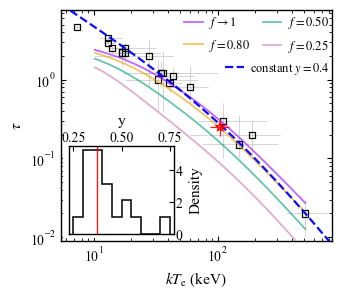

In [38]:
from pathlib import Path

from matplotlib.patches import Rectangle

required_vars = ['kept_df']
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise RuntimeError(
        f"Missing required variables: {missing}. Please run Cells 1-5 first."
    )

apply_mnras_style()
fig, ax = plt.subplots(figsize=get_single_column_size(row_height_scale=1.0))

for article, sub in kept_df.groupby('article', dropna=False):
    xerr = np.vstack([
        sub['kTe_central_keV'] - sub['kTe_lower_keV'],
        sub['kTe_upper_keV'] - sub['kTe_central_keV'],
    ])
    yerr = np.vstack([
        sub['tau_central'] - sub['tau_lower'],
        sub['tau_upper'] - sub['tau_central'],
    ])

    ax.errorbar(
        sub['kTe_central_keV'],
        sub['tau_central'],
        xerr=xerr,
        yerr=yerr,
        fmt='none',
        ecolor='0.7',
        elinewidth=0.7,
        capsize=0,
        alpha=0.55,
        zorder=1,
    )
    ax.scatter(
        sub['kTe_central_keV'],
        sub['tau_central'],
        facecolors='none',
        edgecolors='k',
        marker='s',
        s=20,
        linewidths=0.9,
        alpha=0.95,
        zorder=2,
    )

ricci_kte = 105
ricci_kte_err = 18
ricci_tau = 0.25
ricci_tau_err = 0.06
ricci_theta = ricci_kte / 511
ricci_y = 4 * ricci_theta * (1 + 4 * ricci_theta) * ricci_tau
ax.errorbar(
    [ricci_kte],
    [ricci_tau],
    xerr=[[ricci_kte_err], [ricci_kte_err]],
    yerr=[[ricci_tau_err], [ricci_tau_err]],
    fmt='none',
    ecolor='red',
    elinewidth=0.9,
    capsize=0,
    alpha=0.9,
    zorder=4,
)
ax.scatter(
    [ricci_kte],
    [ricci_tau],
    facecolors='none',
    edgecolors='red',
    marker='*',
    s=45,
    linewidths=1.0,
    alpha=1.0,
    zorder=5,
)

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$kT_{\mathrm{e}}$ (keV)')
ax.set_ylabel(r'$\tau$')
ax.grid(False)


print(f'xlim = ({xlim[0]:.6g}, {xlim[1]:.6g})')
print(f'ylim = ({ylim[0]:.6g}, {ylim[1]:.6g})')

ps96_df = pd.read_csv('data/ps96_slab_dratio_tau_kTe_theta_0.02_1.0_log40.csv').sort_values(['d_ratio', 'kTe_keV'])
ps96_df['f_value'] = 1.0 / (1.0 + ps96_df['d_ratio'])

curve_colors = ["#9900FF", '#E69F00', '#009E73', '#CC79A7']
for color, (d_value, sub) in zip(curve_colors, ps96_df.groupby('d_ratio', sort=True)):
    f_value = 1.0 / (1.0 + d_value)
    ax.plot(
        sub['kTe_keV'],
        sub['tau_T'],
        color=color,
        linewidth=1.3,
        label=fr'$f = {f_value:.2f}$' if np.abs(f_value - 1.0) > 1e-3 else r'$f \rightarrow 1$',
        zorder=3,
        alpha = 0.6
    )


x_curve = np.logspace(np.log10(xlim[0]), np.log10(xlim[1]), 300)
theta_curve = x_curve / 511.0

tau_y0_curve = 0.4 / (4.0 * theta_curve * (1.0 + 4.0 * theta_curve))
valid = np.isfinite(tau_y0_curve) & (tau_y0_curve > 0)
ax.plot(
    x_curve[valid],
    tau_y0_curve[valid],
    linewidth=1.6,
    linestyle='--',
    color='blue',
    alpha=0.95,
    zorder=3,
    label=r'constant $y = 0.4$',
    )


kept_theta = kept_df['kTe_central_keV'] / 511
kept_y = 4 * kept_theta * (1 + 4 * kept_theta) * kept_df['tau_central']
kept_y = kept_y.dropna()
y_bins = np.histogram_bin_edges(np.linspace(0.25, 0.75, 20), bins=10)
ax_inset = ax.inset_axes([0.03, 0.03, 0.39, 0.38])
ax_inset.set_zorder(7)


mask = Rectangle(
    (0.01, 0.01),
    0.4,
    0.5,
    transform=ax.transAxes,
    facecolor='white',
    edgecolor='none',
    zorder=6,
    clip_on=False,
    )
ax.add_patch(mask)
ax_inset.hist(
    kept_y,
    bins=y_bins,
    density=True,
    histtype='step',
    linewidth=1.1,
    color='black',
    )
ax_inset.axvline(ricci_y, color='red', linewidth=1.0, alpha=0.9)
ax_inset.set_xlabel('y')
ax_inset.xaxis.set_label_position('top')
ax_inset.xaxis.tick_top()
ax_inset.set_ylabel('Density')
ax_inset.yaxis.set_label_position('right')
ax_inset.yaxis.tick_right()
ax_inset.tick_params(axis='both', pad=1)
ax_inset.grid(False)
ax_inset.set_facecolor('white')

handles, labels = ax.get_legend_handles_labels()
label_to_handle = {label: handle for handle, label in zip(handles, labels)}

f_labels = [
    r'$f \rightarrow 1$',
    r'$f = 0.80$',
    r'$f = 0.50$',
    r'$f = 0.25$',
]
f_labels = [label for label in f_labels if label in label_to_handle]
f_handles = [label_to_handle[label] for label in f_labels]

legend_f = ax.legend(
    f_handles,
    f_labels,
    frameon=False,
    loc='upper right',
    ncol=2,
    columnspacing=1.0,
    handletextpad=0.5,
    handlelength=1.5,
    bbox_to_anchor=(1.03, 1.03),
)
ax.add_artist(legend_f)

const_label = r'constant $y = 0.4$'
if const_label in label_to_handle:
    ax.legend(
        [label_to_handle[const_label]],
        [const_label],
        frameon=False,
        ncol=1,
        handletextpad=0.5,
        handlelength=1.5,
        loc='upper left',
        bbox_to_anchor=(0.565, 0.83),
    )

fig.savefig(FIGURE_DIR / 'final_results.pdf', dpi=300, bbox_inches='tight')
plt.show()

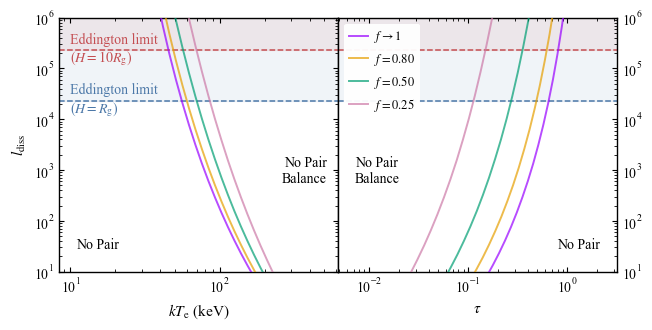

In [39]:
from plot_style import get_double_column_size

apply_mnras_style()

ps96_df = pd.read_csv('data/ps96_slab_dratio_tau_kTe_theta_0.02_1.0_log40.csv').sort_values(['d_ratio', 'kTe_keV'])
curve_colors = ["#9900FF", '#E69F00', '#009E73', '#CC79A7']
line_specs = [
    (2.3e4, '#4C78A8', r'Eddington limit ($H = R_{\rm g}$)'),
    (2.3e5, '#C44E52', r'Eddington limit ($H = 10R_{\rm g}$)'),
]
ymin, ymax = 10, 1.0e6

fig, (ax_left, ax_right) = plt.subplots(
    1,
    2,
    figsize=get_double_column_size(row_height_scale=1.1),
    sharey=True,
    gridspec_kw={'wspace': 0.0},
)

for ax in (ax_left, ax_right):
    for y_value, color, _ in line_specs:
        ax.axhspan(y_value, ymax, color=color, alpha=0.08, zorder=0)

for color, (d_value, sub) in zip(curve_colors, ps96_df.groupby('d_ratio', sort=True)):
    f_value = 1.0 / (1.0 + d_value)
    label = fr'$f = {f_value:.2f}$' if np.abs(f_value - 1.0) > 1e-3 else r'$f \rightarrow 1$'

    ax_left.plot(
        sub['kTe_keV'],
        sub['l_diss_local'],
        color=color,
        linewidth=1.4,
        alpha=0.7,
        label=label,
        zorder=3,
    )
    ax_right.plot(
        sub['tau_T'],
        sub['l_diss_local'],
        color=color,
        linewidth=1.4,
        alpha=0.7,
        zorder=3,
    )

for y_value, color, label in line_specs:
    ax_left.axhline(y_value, color=color, linewidth=1.1, linestyle='--', zorder=2)
    ax_right.axhline(y_value, color=color, linewidth=1.1, linestyle='--', zorder=2)

ax_left.text(10, 1.e4 * 1.06, 'Eddington limit\n' + r'($H = R_{\rm g}$)', color='#4C78A8', ha='left', va='bottom')
ax_left.text(10, 1e5 * 1.06, 'Eddington limit\n' + r'($H = 10R_{\rm g}$)', color='#C44E52', ha='left', va='bottom')

ax_left.set_xscale('log')
ax_left.set_yscale('log')
ax_left.set_xlabel(r'$kT_{\mathrm{e}}$ (keV)')
ax_left.set_ylabel(r'$l_{\mathrm{diss}}$')
ax_left.set_ylim(ymin, ymax)
ax_left.grid(False)

ax_right.set_xscale('log')
ax_right.set_xlabel(r'$\tau$')
ax_right.grid(False)
ax_right.yaxis.set_label_position('right')
ax_right.yaxis.tick_right()
ax_right.tick_params(axis='y', which='both', left=False, labelleft=False, right=True, labelright=True)

ax_left.text(0.06, 0.08, 'No Pair', transform=ax_left.transAxes, ha='left', va='bottom')
ax_left.text(0.96, 0.4, 'No Pair\nBalance', transform=ax_left.transAxes, ha='right', va='center')
ax_right.text(0.94, 0.08, 'No Pair', transform=ax_right.transAxes, ha='right', va='bottom')
ax_right.text(0.06, 0.4, 'No Pair\nBalance', transform=ax_right.transAxes, ha='left', va='center')

handles, labels = ax_left.get_legend_handles_labels()
ax_right.legend(
    handles,
    labels,
    frameon=True,
    facecolor='white',
    framealpha=0.95,
    edgecolor='none',
    ncol=1,
    columnspacing=1.0,
    handletextpad=0.5,
    handlelength=1.5,
    loc='upper left',
)

fig.savefig(FIGURE_DIR / 'pair_balance.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'pair_balance.png', dpi=300, bbox_inches='tight')

plt.show()
